# ResNet-18 (Augmented + LR Scheduler)

## Changes from Unfreeze Baseline

### What changed
| | Unfreeze | Augmented v1 |
|---|---|---|
| Augmentation | HFlip + ±10° rotation | HFlip + VFlip + ±30° rotation + ColorJitter + RandomAffine |
| Weight decay | None | 1e-4 |
| LR scheduler | None | CosineAnnealingLR |

### Rationale
The unfreeze model overfits heavily — train F2 reaches 0.97 while val F2 peaks at 0.78. Two changes target this:

1. **Stronger augmentation**: More transforms (vertical flip, wider rotation, color jitter, affine shifts) force the model to learn general melanoma features rather than memorizing specific training images. Skin lesion images have no natural orientation, so flips and rotations are valid.

2. **Weight decay + cosine LR schedule**: Weight decay (L2 regularization) penalizes large weights to prevent overfitting. Cosine annealing gradually reduces the learning rate, allowing the model to settle into a better minimum rather than oscillating.

In [1]:
import sys
import os
from pathlib import Path

# Find project root regardless of CWD (works in VS Code, Jupyter Lab, etc.)
ROOT = next(p for p in [Path.cwd()] + list(Path.cwd().parents) if (p / 'src').exists())
sys.path.insert(0, str(ROOT))

import pandas as pd

import torch
import torch.nn as nn
import torch.optim as optim
from torch.optim.lr_scheduler import CosineAnnealingLR

from src.data.dataloader import get_dataloaders
from src.data.transform import get_augmented_train_transforms
from src.models.resnet import get_resnet
from src.training.trainer import train_one_epoch, validate_one_epoch
from src.utils import plot_training_curves, find_best_threshold, evaluate_model

os.chdir(ROOT)
print(Path.cwd())

c:\Users\Dylan Gay\Documents\SUTD\Deep Learning\50.039-Deep-Learning


In [2]:
import random
import numpy as np

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.mps.manual_seed(seed)

set_seed(42)

In [3]:
if torch.cuda.is_available():
    device = torch.device('cuda')
elif torch.backends.mps.is_available():
    device = torch.device('mps')
else:
    device = torch.device('cpu')
print(f'Using device: {device}')

Using device: cuda


In [4]:
train_loader, val_loader, test_loader = get_dataloaders(
    train_csv=str(ROOT / 'data_new/splits/train.csv'),
    val_csv=str(ROOT / 'data_new/splits/val.csv'),
    test_csv=str(ROOT / 'data_new/splits/test.csv'),
    image_dir=str(ROOT / 'data_new/images/train'),
    test_image_dir=str(ROOT / 'data_new/images/test'),
    batch_size=32,
    image_size=224,
    num_workers=0,
    transform_train=get_augmented_train_transforms(image_size=224),
)

train_df = pd.read_csv(ROOT / 'data_new/splits/train.csv')

num_melanoma = (train_df['label'] == 1).sum()   # melanoma in CSV (label=1)
num_nevus = (train_df['label'] == 0).sum()      # nevus in CSV (label=0)

pos_weight = torch.tensor([num_nevus / num_melanoma], dtype=torch.float32).to(device)

print('Positive weight:', pos_weight)

model = get_resnet(num_classes=1, freeze_backbone=False).to(device)
criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
optimizer = optim.Adam(model.parameters(), lr=1e-4, weight_decay=1e-4)

num_epochs = 20
scheduler = CosineAnnealingLR(optimizer, T_max=num_epochs)

Positive weight: tensor([8.1117], device='cuda:0')


In [5]:
best_val_f2 = 0.0
train_history, val_history = [], []

for epoch in range(num_epochs):
    train_metrics = train_one_epoch(model, train_loader, criterion, optimizer, device)
    val_metrics = validate_one_epoch(model, val_loader, criterion, device)

    scheduler.step()

    train_history.append(train_metrics)
    val_history.append(val_metrics)

    print(
        f"Epoch [{epoch+1}/{num_epochs}] | "
        f"Train Loss: {train_metrics['loss']:.4f}, Bal Acc: {train_metrics['balanced_accuracy']:.4f}, "
        f"Recall: {train_metrics['recall']:.4f}, F2: {train_metrics['f2']:.4f} | "
        f"Val Loss: {val_metrics['loss']:.4f}, Bal Acc: {val_metrics['balanced_accuracy']:.4f}, "
        f"Recall: {val_metrics['recall']:.4f}, F2: {val_metrics['f2']:.4f}"
    )

    if val_metrics['f2'] > best_val_f2:
        best_val_f2 = val_metrics['f2']
        torch.save(model.state_dict(), 'models/resnet_augmented_v1_best.pth')
        print('Saved best model at epoch', epoch+1)

Epoch [1/20] | Train Loss: 0.9070, Bal Acc: 0.7411, Recall: 0.7902, F2: 0.5421 | Val Loss: 0.8955, Bal Acc: 0.7750, Recall: 0.8263, F2: 0.5971
Saved best model at epoch 1


Epoch [2/20] | Train Loss: 0.7921, Bal Acc: 0.7879, Recall: 0.8381, F2: 0.6016 | Val Loss: 0.8831, Bal Acc: 0.7778, Recall: 0.7458, F2: 0.6027
Saved best model at epoch 2


Epoch [3/20] | Train Loss: 0.7637, Bal Acc: 0.7955, Recall: 0.8278, F2: 0.6133 | Val Loss: 0.7761, Bal Acc: 0.7901, Recall: 0.8178, F2: 0.6178
Saved best model at epoch 3


Epoch [4/20] | Train Loss: 0.7127, Bal Acc: 0.8067, Recall: 0.8449, F2: 0.6284 | Val Loss: 0.8173, Bal Acc: 0.7923, Recall: 0.7881, F2: 0.6225
Saved best model at epoch 4


Epoch [5/20] | Train Loss: 0.6780, Bal Acc: 0.8214, Recall: 0.8518, F2: 0.6506 | Val Loss: 0.8961, Bal Acc: 0.7755, Recall: 0.6695, F2: 0.6012


...

Epoch [16/20] | Train Loss: 0.3527, Bal Acc: 0.9248, Recall: 0.9532, F2: 0.8227 | Val Loss: 1.0354, Bal Acc: 0.7903, Recall: 0.6992, F2: 0.6245


Epoch [17/20] | Train Loss: 0.3209, Bal Acc: 0.9274, Recall: 0.9464, F2: 0.8317 | Val Loss: 1.2059, Bal Acc: 0.7761, Recall: 0.6483, F2: 0.6028


Epoch [18/20] | Train Loss: 0.3162, Bal Acc: 0.9237, Recall: 0.9396, F2: 0.8260 | Val Loss: 1.0501, Bal Acc: 0.7965, Recall: 0.7076, F2: 0.6345


Epoch [19/20] | Train Loss: 0.2887, Bal Acc: 0.9403, Recall: 0.9612, F2: 0.8560 | Val Loss: 1.1467, Bal Acc: 0.7829, Recall: 0.6653, F2: 0.6138


Epoch [20/20] | Train Loss: 0.2902, Bal Acc: 0.9291, Recall: 0.9453, F2: 0.8362 | Val Loss: 1.1697, Bal Acc: 0.7757, Recall: 0.6525, F2: 0.6020


## Training Curves

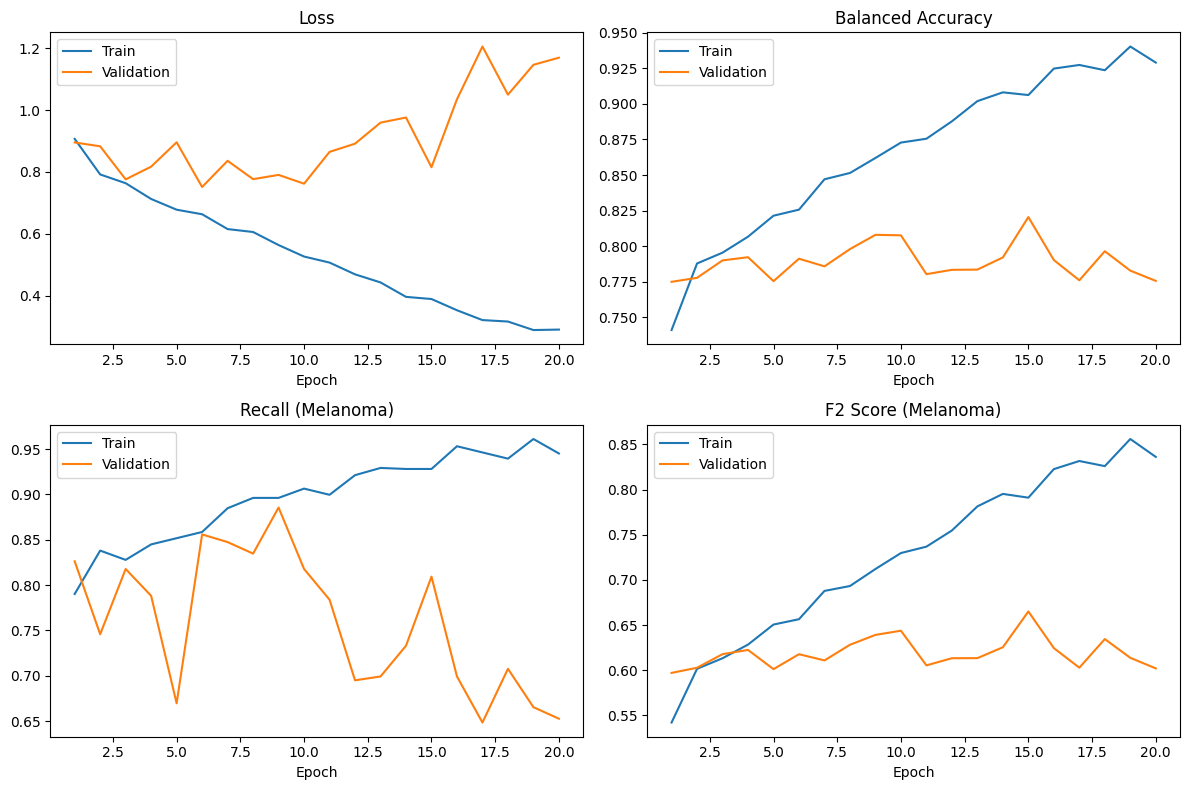

In [6]:
plot_training_curves(train_history, val_history)

## Threshold Tuning

In [7]:
model.load_state_dict(torch.load(str(ROOT / 'models/resnet_augmented_v1_best.pth'), map_location=device))
best_threshold, best_f2 = find_best_threshold(model, val_loader, device)

Best threshold: 0.44 | Val F2: 0.6680


Threshold:          0.44
AUC-ROC:            0.9068
Balanced Accuracy:  0.8257
F2 Score:           0.6660

              precision    recall  f1-score   support

Non-Melanoma     0.9743    0.8209    0.8910      1340
    Melanoma     0.3717    0.8304    0.5136       171

    accuracy                         0.8220      1511
   macro avg     0.6730    0.8257    0.7023      1511
weighted avg     0.9061    0.8220    0.8483      1511



c:\Users\Dylan Gay\Documents\SUTD\Deep Learning\50.039-Deep-Learning\dl_venv\Lib\site-packages\sklearn\utils\_plotting.py:385: FutureWarning: `estimator_name` is deprecated in 1.7 and will be removed in 1.9. Use `name` instead.
  warnings.warn(


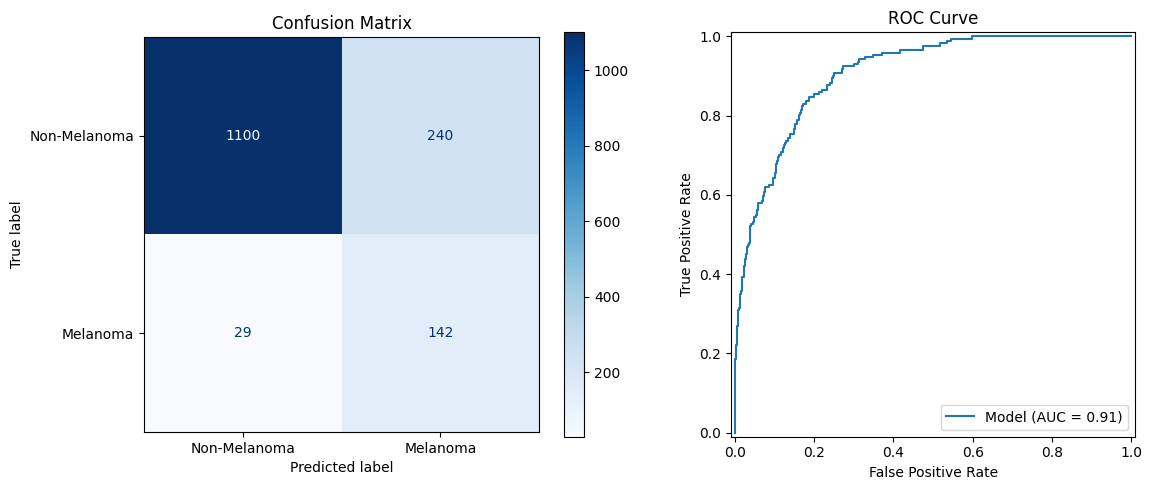

In [8]:
evaluate_model(model, test_loader, device, threshold=best_threshold)